<p estilo="text-align:centro">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Logotipo de Skills Network">
    </a>
</p>


# **Predicción del aterrizaje de la primera etapa del SpaceX Falcon 9**


## Laboratorio práctico: complete el EDA con visualización


Tiempo estimado necesario: **70** minutos


En esta tarea, predeciremos si la primera etapa del Falcon 9 aterrizará con éxito. SpaceX anuncia en su sitio web lanzamientos de cohetes Falcon 9 con un costo de 62 millones de dólares; Otros proveedores cuestan más de 165 millones de dólares cada uno, gran parte del ahorro se debe al hecho de que SpaceX puede reutilizar la primera etapa. 

En esta práctica de laboratorio, realizará análisis de datos exploratorios e ingeniería de funciones.


La primera etapa del Falcon 9 aterrizará con éxito


![](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DS0701EN-SkillsNetwork/api/Images/landing_1.gif)


A continuación se muestran varios ejemplos de un aterrizaje fallido:


![](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DS0701EN-SkillsNetwork/api/Images/crash.gif)


Se planean la mayoría de los aterrizajes fallidos. Space X realiza un aterrizaje controlado en los océanos.


## Objetivos
Realice análisis de datos exploratorios e ingeniería de funciones utilizando `Pandas` y `Matplotlib`

- Análisis de datos exploratorios
- Preparación de la ingeniería de funciones de datos


Instale las siguientes bibliotecas


In [ ]:
!pip install pandas
!pip install numpy
!pip install seaborn
!pip install matplotlib

### Importar bibliotecas y definir funciones auxiliares


Importaremos las siguientes bibliotecas al laboratorio.


In [1]:
# andas es una biblioteca de software escrita para el lenguaje de programación Python para la manipulación y análisis de datos.
import pandas as pd
# NumPy es una biblioteca para el lenguaje de programación Python, que agrega soporte para matrices y arreglos multidimensionales grandes, junto con una gran colección de funciones matemáticas de alto nivel para operar en estos arreglos.
import numpy as np
# Matplotlib es una biblioteca de trazado para Python y pyplot nos proporciona un marco de trazado similar a MatLab. Usaremos esto en nuestra función de trazador para trazar datos.
import matplotlib.pyplot as plt
# Seaborn es una biblioteca de visualización de datos de Python basada en matplotlib. Proporciona una interfaz de alto nivel para dibujar gráficos estadísticos atractivos e informativos.
import seaborn as sns

## Análisis de datos exploratorios


Primero, leamos el conjunto de datos de SpaceX en un marco de datos de Pandas e imprimamos su resumen.


In [2]:
df=pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv")

# Si no pudo completar la práctica de laboratorio anterior correctamente, puede descomentar y cargar este csv.

# df = pd.read_csv('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DS0701EN-SkillsNetwork/api/dataset_part_2.csv')

df.head(5)

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010-06-04,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0


Primero, intentemos ver cómo las variables `FlightNumber` (que indica los intentos de lanzamiento continuos) y `Payload` afectarían el resultado del lanzamiento.

Podemos trazar el <code>FlightNumber</code> frente a <code>PayloadMass</code> y superponer el resultado del lanzamiento. Vemos que a medida que aumenta el número de vuelos, es más probable que la primera etapa aterrice con éxito. La masa de la carga útil también es importante; Parece que cuanto más masiva es la carga útil, es menos probable que regrese la primera etapa.


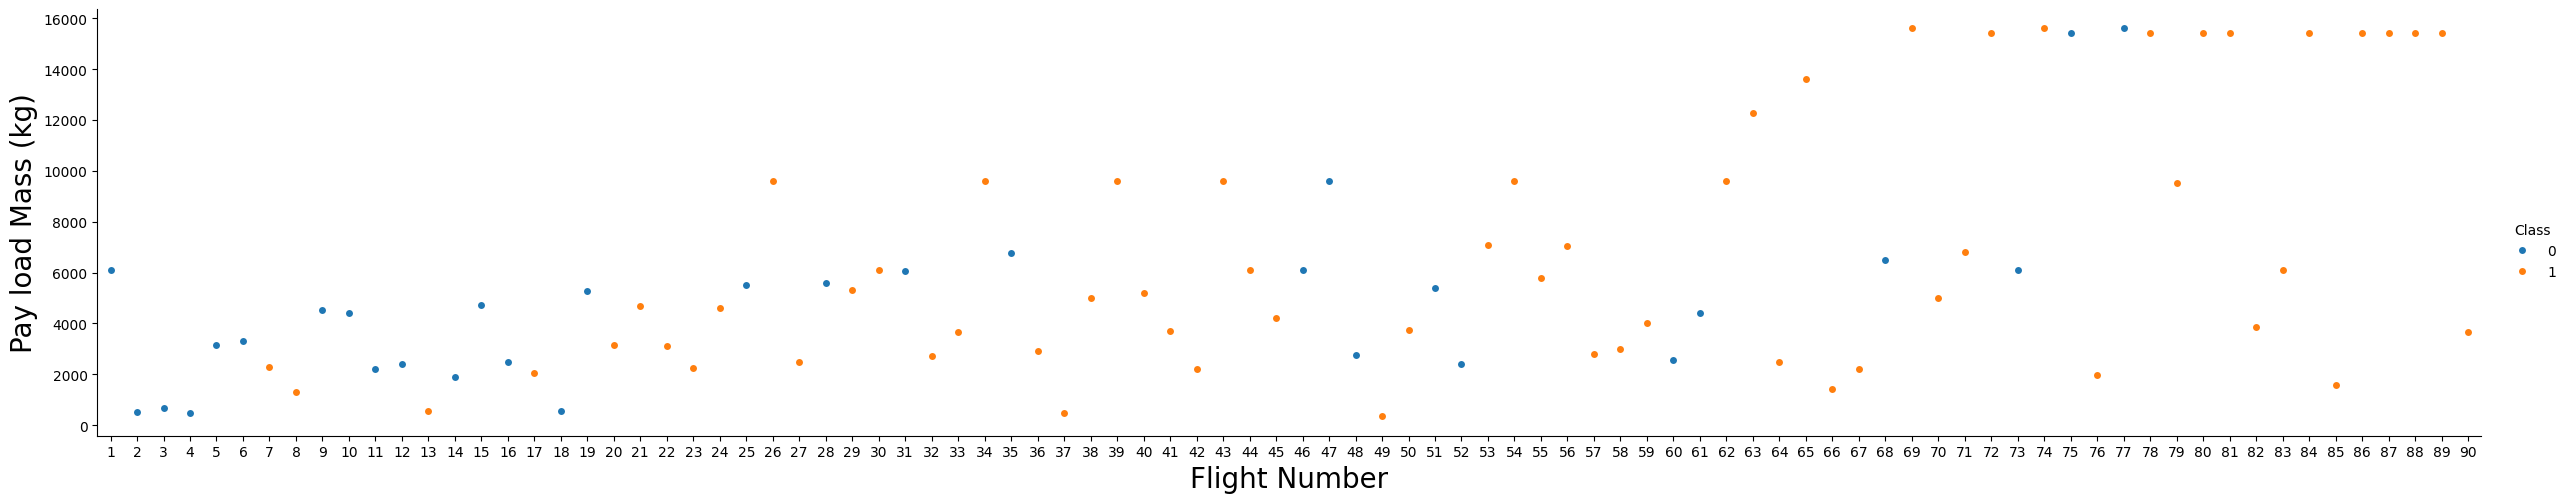

In [3]:
sns.catplot(y="PayloadMass", x="FlightNumber", hue="Class", data=df, aspect = 5)
plt.xlabel("Flight Number",fontsize=20)
plt.ylabel("Pay load Mass (kg)",fontsize=20)
plt.show()

A continuación, profundicemos en cada sitio y visualicemos sus registros de lanzamiento detallados.


### TAREA 1: Visualizar la relación entre el número de vuelo y el sitio de lanzamiento


Utilice la función <code>catplot</code> para trazar <code>FlightNumber</code> frente a <code>LaunchSite</code>, establezca el parámetro <code>x</code> en <code>FlightNumber</code>, establezca <code>y</code> en <code>Launch Site</code> y establezca el parámetro <code>hue</code> en <code>'class'</code>.


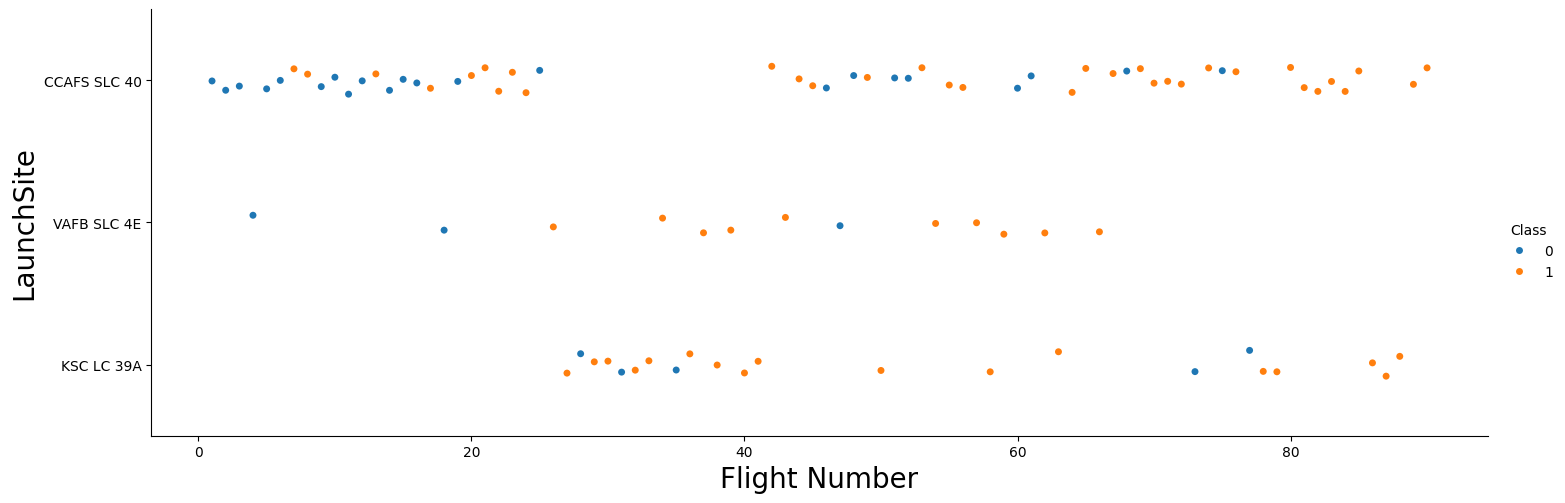

In [7]:
sns.catplot(y="LaunchSite", x="FlightNumber", hue='Class', data=df, aspect = 3)
plt.xlabel("Flight Number",fontsize=20)
plt.ylabel("LaunchSite", fontsize=20)
plt.show()

Ahora intente explicar los patrones que encontró en los gráficos de puntos de dispersión del número de vuelo frente al sitio de lanzamiento.


### TAREA 2: Visualizar la relación entre la carga útil y el sitio de lanzamiento


También queremos observar si existe alguna relación entre los sitios de lanzamiento y su masa de carga útil.


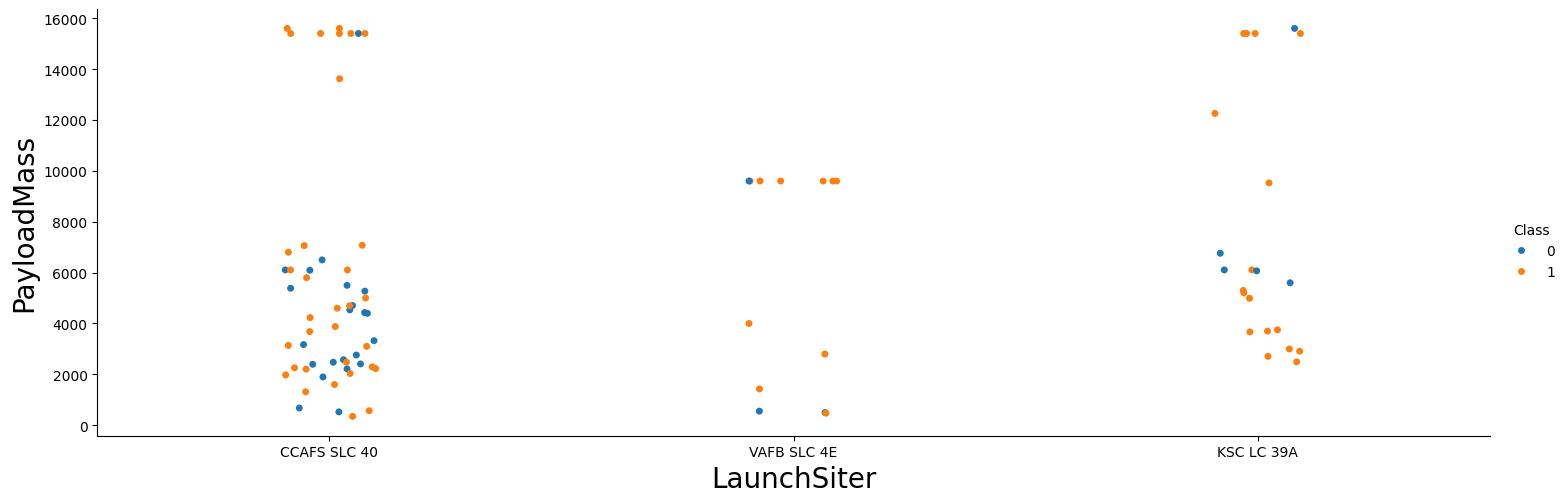

In [8]:
sns.catplot(y="PayloadMass", x="LaunchSite", hue='Class', data=df, aspect = 3)
plt.xlabel("LaunchSite",fontsize=20)
plt.ylabel("PayloadMass", fontsize=20)
plt.show()

Ahora, si observas Payload vs LaunchSite.En el gráfico de puntos de dispersión del sitio de lanzamiento que encontrará para el sitio de lanzamiento VAFB-SLC, no se lanzan cohetes con una masa de carga pesada (superior a 10000).


### TAREA 3: Visualizar la relación entre la tasa de éxito de cada tipo de órbita


A continuación, queremos comprobar visualmente si existe alguna relación entre la tasa de éxito y el tipo de órbita.


Creemos un "gráfico de barras" para la tasa de éxito de cada órbita.


<Axes: xlabel='Orbit', ylabel='Class'>

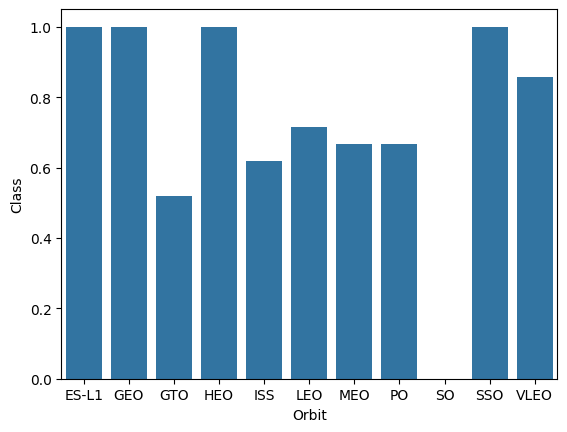

In [11]:
sns.barplot(x='Orbit', y='Class', data=df.groupby('Orbit')['Class'].mean().reset_index())

Analice el gráfico de barras trazado y trate de encontrar qué órbitas tienen una alta tasa de éxito.


### TAREA 4: Visualizar la relación entre FlightNumber y tipo de órbita


Para cada órbita, queremos ver si existe alguna relación entre FlightNumber y el tipo de órbita.


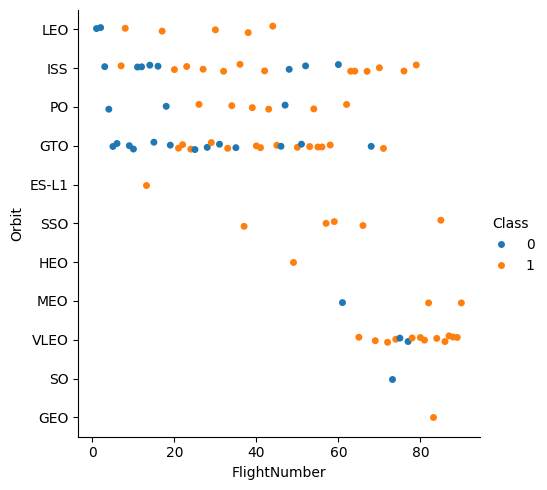

In [14]:
sns.catplot(y='Orbit', x='FlightNumber', data=df, hue='Class')

Deberías ver que en la órbita LEO aparece el Éxito relacionado con la cantidad de vuelos; por otro lado, no parece haber relación entre el número de vuelo cuando se encuentra en órbita GTO.


### TAREA 5: Visualizar la relación entre la carga útil y el tipo de órbita


De manera similar, podemos trazar los gráficos de puntos de dispersión de carga útil versus órbita para revelar la relación entre la carga útil y el tipo de órbita.


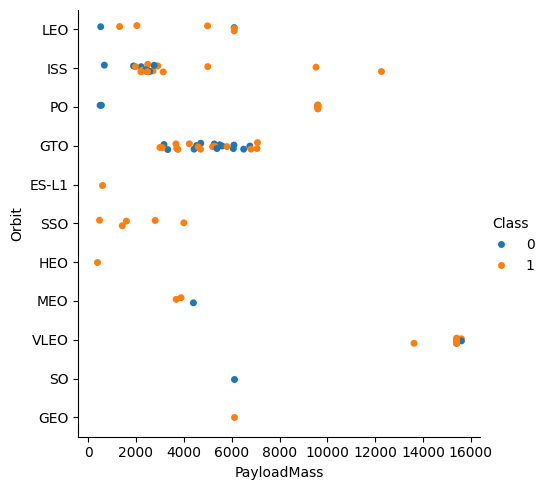

In [15]:
sns.catplot(y='Orbit', x='PayloadMass', data=df, hue='Class')

Con cargas útiles pesadas, la tasa de aterrizaje exitoso o positivo es mayor para Polar, LEO e ISS.   

Sin embargo, para GTO no podemos distinguir esto bien ya que tanto la tasa de aterrizaje positiva como la tasa de aterrizaje negativa (misión fallida) están presentes aquí.


### TAREA 6: Visualizar la tendencia anual de éxito del lanzamiento


Puede trazar un gráfico de líneas con el eje x como <code>Año</code> y el eje y como la tasa de éxito promedio, para obtener la tendencia promedio de éxito de lanzamiento.


La función le ayudará a obtener el año a partir de la fecha:


In [26]:
# Una función para extraer años de la fecha.
year=[]
def Extract_year(date):
    for i in df["Date"]:
        year.append(i.split("-")[0])
    return year

df['Year'] = Extract_year(df['Date']) 

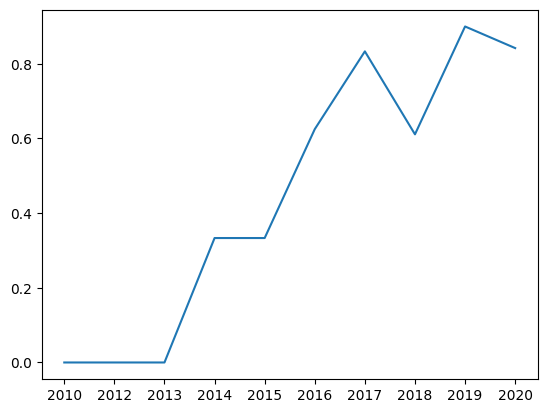

In [33]:
plt.plot(df['Year'].unique(), df.groupby('Year')['Class'].mean().values)

Se puede observar que la tasa de éxito desde 2013 siguió aumentando hasta 2017 (estable en 2014) y después de 2015 comenzó a aumentar.


## Ingeniería de características


A estas alturas, debería obtener algunos conocimientos preliminares sobre cómo cada variable importante afectaría la tasa de éxito; seleccionaremos las características que se utilizarán en la predicción del éxito en el módulo futuro.


In [34]:
features = df[['FlightNumber', 'PayloadMass', 'Orbit', 'LaunchSite', 'Flights', 'GridFins', 'Reused', 'Legs', 'LandingPad', 'Block', 'ReusedCount', 'Serial']]
features.head()

,FlightNumber,PayloadMass,Orbit,LaunchSite,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial
0,1,6104.959412,LEO,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B0003
1,2,525.000000,LEO,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B0005
2,3,677.000000,ISS,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B0007
3,4,500.000000,PO,VAFB SLC 4E,1,False,False,False,NaN,1.0,0,B1003
4,5,3170.000000,GTO,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B1004


### TAREA 7: Crear variables ficticias para columnas categóricas


Utilice la función <code>get_dummies</code> y el marco de datos <code>features</code> para aplicar OneHotEncoder a la columna <code>Orbits</code>, <code>LaunchSite</code>, <code>LandingPad</code> y <code>Serial</code>. Asigne el valor a la variable <code>features_one_hot</code>, muestre los resultados usando el encabezado del método. Su marco de datos de resultados debe incluir todas las funciones, incluidas las codificadas.


In [37]:
features_one_hot = pd.get_dummies(features)
features_one_hot.head()

,FlightNumber,PayloadMass,Flights,GridFins,Reused,Legs,Block,ReusedCount,Orbit_ES-L1,Orbit_GEO,...,Serial_B1048,Serial_B1049,Serial_B1050,Serial_B1051,Serial_B1054,Serial_B1056,Serial_B1058,Serial_B1059,Serial_B1060,Serial_B1062
0,1,6104.959412,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False
1,2,525.000000,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False
2,3,677.000000,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False
3,4,500.000000,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False
4,5,3170.000000,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False


### TAREA 8: Transmitir todas las columnas numéricas a `float64`


Ahora que nuestro marco de datos <code>features_one_hot</code> solo contiene números, convierta el marco de datos completo al tipo de variable <code>float64</code>


In [38]:
features_one_hot = features_one_hot.astype('float64')

Ahora podemos exportarlo a un <b>CSV</b> para la siguiente sección, pero para que las respuestas sean consistentes, en la próxima práctica de laboratorio proporcionaremos datos en un rango de fechas preseleccionado.


In [39]:
features_one_hot.to_csv('dataset_part_3.csv', index=False)


In [41]:
features_one_hot.shape

(90, 80)